# **تشخیص کرایه های غیر معمول با مدل پیشرفته برگرفته از شبکه عصبی**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
file_path = '/content/drive/My Drive/Zahra/Year_403.xlsx'
df = pd.read_excel(file_path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Value added insurance premium,Received from the driver,Scale fee,Evacuation fee,added value,Complications of moving goods,Bill of lading registration time,Tracking code watch,date of interception,Company commission,...,product code,distance,weight,Calculation fare,rent,Bill of lading number,Bill of lading series,Company name,Company Code,year
0,144000,12669000,0,0,0,5616000,14:04,14:05,1403/01/05,5,...,6650400,148,22000,62400000,62400000,3542008,1402/14,بلم لجستيک,111100195,1403
1,144000,12669000,0,0,0,5616000,13:21,13:22,1403/01/05,4992000,...,6650400,148,22000,62400000,62400000,3542007,1402/14,بلم لجستيک,111100195,1403
2,144000,12704000,0,0,0,5634000,13:12,13:13,1403/01/05,5008000,...,6650400,148,22000,62600000,62600000,3542005,1402/14,بلم لجستيک,111100195,1403
3,144000,12704000,0,0,0,5634000,13:16,13:17,1403/01/05,5008000,...,6650400,148,22000,62600000,62600000,3542006,1402/14,بلم لجستيک,111100195,1403
4,81000,647500,0,0,0,1665000,13:28,13:33,1403/01/05,1480000,...,5600701,370,2100,18500000,18500000,3680279,1402/14,خليج فارس (تهران ),111100459,1403


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601217 entries, 0 to 601216
Data columns (total 43 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Value added insurance premium     601217 non-null  int64  
 1   Received from the driver          601217 non-null  int64  
 2   Scale fee                         601217 non-null  int64  
 3   Evacuation fee                    601217 non-null  int64  
 4   added value                       601217 non-null  int64  
 5   Complications of moving goods     601217 non-null  int64  
 6   Bill of lading registration time  601217 non-null  object 
 7   Tracking code watch               601217 non-null  object 
 8   date of interception              601217 non-null  object 
 9   Company commission                601217 non-null  int64  
 10  Insurance amount                  601217 non-null  int64  
 11  Loading fee                       601217 non-null  i

In [ ]:
!pip install jdatetime

In [ ]:
import pandas as pd
import jdatetime

print(" قبل از تبدیل:")
print(df['Date of issue'])
print(df['Date of issue'].dtype)  # نوع ستون قبل از تبدیل

# تابع تبدیل شمسی به میلادی
def shamsi_to_gregorian(date_str):
    try:
        y, m, d = map(int, date_str.split('/'))
        return jdatetime.date(y, m, d).togregorian()
    except:
        return None  # اگه تاریخ خراب بود یا NaN بود

# تبدیل به میلادی
df['Date of issue'] = df['Date of issue'].apply(shamsi_to_gregorian)

# تبدیل نوع ستون به datetime پانداس
df['Date of issue'] = pd.to_datetime(df['Date of issue'])

print("\n بعد از تبدیل:")
print(df['Date of issue'])
print(df['Date of issue'].dtype)  # نوع ستون بعد از تبدیل

 قبل از تبدیل:
0         1403/01/05
1         1403/01/05
2         1403/01/05
3         1403/01/05
4         1403/01/05
             ...    
601212    1403/12/27
601213    1403/12/27
601214    1403/12/28
601215    1403/12/28
601216    1403/12/27
Name: Date of issue, Length: 601217, dtype: object
object

 بعد از تبدیل:
0        2024-03-24
1        2024-03-24
2        2024-03-24
3        2024-03-24
4        2024-03-24
            ...    
601212   2025-03-17
601213   2025-03-17
601214   2025-03-18
601215   2025-03-18
601216   2025-03-17
Name: Date of issue, Length: 601217, dtype: datetime64[ns]
datetime64[ns]


In [ ]:
import pandas as pd
import jdatetime

print(" قبل از تبدیل:")
print(df['Delivery date'])
print(df['Delivery date'].dtype)

def shamsi_to_gregorian(date_str):
    try:
        y, m, d = map(int, date_str.split('/'))
        return jdatetime.date(y, m, d).togregorian()
    except:
        return None

df['Delivery date'] = df['Delivery date'].apply(shamsi_to_gregorian)

df['Delivery date'] = pd.to_datetime(df['Delivery date'])

print("\n بعد از تبدیل:")
print(df['Delivery date'])
print(df['Delivery date'].dtype)

 قبل از تبدیل:
0         1403/01/06
1         1403/01/06
2         1403/01/06
3         1403/01/06
4         1403/01/06
             ...    
601212    1403/12/28
601213    1403/12/28
601214    1403/12/29
601215    1403/12/29
601216    1403/12/28
Name: Delivery date, Length: 601217, dtype: object
object

 بعد از تبدیل:
0        2024-03-25
1        2024-03-25
2        2024-03-25
3        2024-03-25
4        2024-03-25
            ...    
601212   2025-03-18
601213   2025-03-18
601214   2025-03-19
601215   2025-03-19
601216   2025-03-18
Name: Delivery date, Length: 601217, dtype: datetime64[ns]
datetime64[ns]


In [ ]:
df['Bill of lading registration time'].head()

,Bill of lading registration time
0,2025-08-07 14:04:00
1,2025-08-07 13:21:00
2,2025-08-07 13:12:00
3,2025-08-07 13:16:00
4,2025-08-07 13:28:00


In [ ]:
df['Bill of lading registration time'].head()

,Bill of lading registration time
0,2025-08-07 14:04:00
1,2025-08-07 13:21:00
2,2025-08-07 13:12:00
3,2025-08-07 13:16:00
4,2025-08-07 13:28:00


In [ ]:
import pandas as pd
import numpy as np

df['reg_datetime'] = pd.to_datetime(df['Bill of lading registration time'])

df['hour'] = df['reg_datetime'].dt.hour
df['day_of_week'] = df['reg_datetime'].dt.dayofweek  # دوشنبه=0, ..., یکشنبه=6
df['month'] = df['reg_datetime'].dt.month
df['day_of_month'] = df['reg_datetime'].dt.day

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

In [ ]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

features = df[[
    'Calculation fare',  # کرایه
    'distance',          # مسافت
    'weight',            # وزن
    'hour_sin',          # ساعت (تبدیل سیکلیک)
    'hour_cos',
    'dow_sin',           # روز هفته (تبدیل سیکلیک)
    'dow_cos'
]]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

class SVDDNet(nn.Module):
    def __init__(self, input_dim=7):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8)  # فضای نهان کم‌بعد
        )

    def forward(self, x):
        return self.encoder(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SVDDNet().to(device)

init_data = torch.tensor(scaled_data[:1000], dtype=torch.float32).to(device)
with torch.no_grad():
    c = torch.mean(model(init_data), dim=0).detach()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
data_tensor = torch.tensor(scaled_data, dtype=torch.float32).to(device)

for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(data_tensor)
    distances = torch.sum((outputs - c) ** 2, dim=1)
    loss = torch.mean(distances)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

with torch.no_grad():
    latent_vectors = model(data_tensor)
    distances = torch.sum((latent_vectors - c) ** 2, dim=1).cpu().numpy()

threshold = np.quantile(distances, 0.95)
df['anomaly_score'] = distances
df['is_anomaly'] = (df['anomaly_score'] > threshold).astype(int)

Epoch 0, Loss: 0.0263
Epoch 10, Loss: 0.0108
Epoch 20, Loss: 0.0052
Epoch 30, Loss: 0.0028
Epoch 40, Loss: 0.0017
Epoch 50, Loss: 0.0011
Epoch 60, Loss: 0.0008
Epoch 70, Loss: 0.0006
Epoch 80, Loss: 0.0004
Epoch 90, Loss: 0.0004


# **همگرایی مدل**

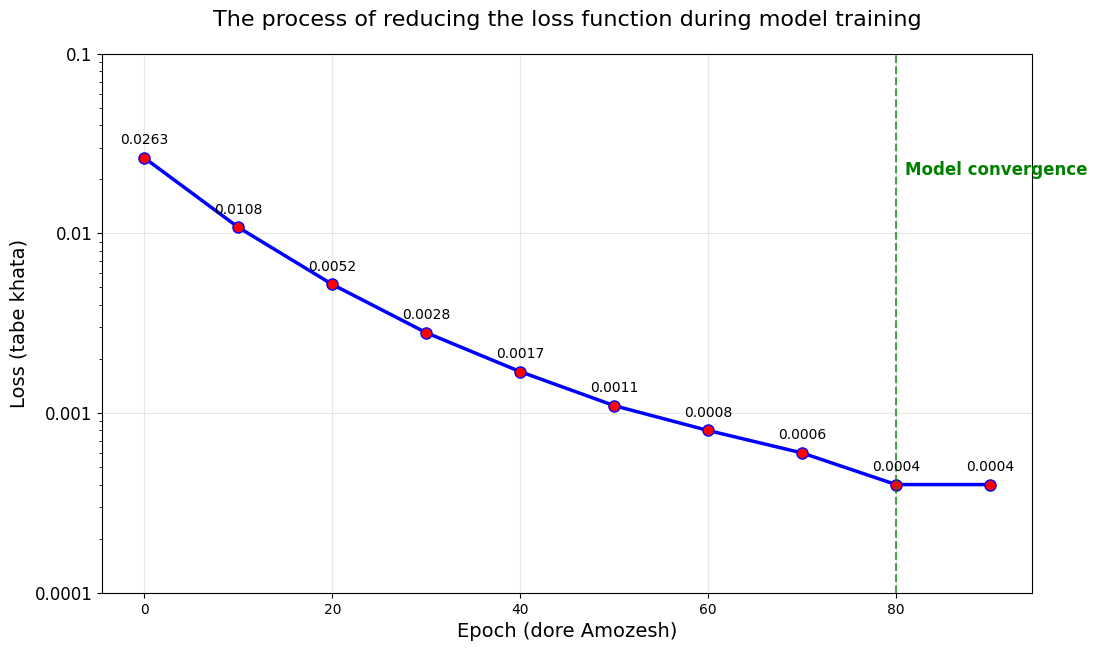

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
losses = [0.0263, 0.0108, 0.0052, 0.0028, 0.0017, 0.0011, 0.0008, 0.0006, 0.0004, 0.0004]

plt.figure(figsize=(12, 7))
plt.plot(epochs, losses, 'bo-', linewidth=2.5, markersize=8, markerfacecolor='red')

convergence_point = 80
plt.axvline(x=convergence_point, color='g', linestyle='--', alpha=0.7)
plt.text(convergence_point+1, max(losses)*0.8, 'Model convergence',
         fontsize=12, color='g', weight='bold')

plt.title('The process of reducing the loss function during model training', fontsize=16, pad=20)
plt.xlabel('Epoch (dore Amozesh)', fontsize=14)
plt.ylabel('Loss (tabe khata)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.yscale('log')
plt.yticks([0.0001, 0.001, 0.01, 0.1],
           ['0.0001', '0.001', '0.01', '0.1'],
           fontsize=12)

for i, (epoch, loss) in enumerate(zip(epochs, losses)):
    plt.annotate(f'{loss:.4f}',
                 (epoch, loss),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center',
                 fontsize=10)

plt.savefig('loss_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

تعداد ناهنجاری‌ها: 30061
        Bill of lading number        Company name  Calculation fare  \
537392                3972884           قصربار قم        2937541172   
430101                7931611           قصربار قم        2004184100   
115772                 887698           قصربار قم        1494543180   
185934                6921963  مرکز بار بهاران قم        1588020765   
517345                3971848           قصربار قم        1414225941   
287979                1070020           قصربار قم        1422594141   
448050                4214093  مرکز بار بهاران قم        1260292521   
433638                2584091   سعدي سير (تهران )        1216425532   
182199                6931918     تيز پانورد جاده         900000000   
582357                7337187           قصربار قم        1037875900   

        anomaly_score  
537392       0.464161  
430101       0.207174  
115772       0.134020  
185934       0.132971  
517345       0.109262  
287979       0.108889  
448050       0.087099  
4

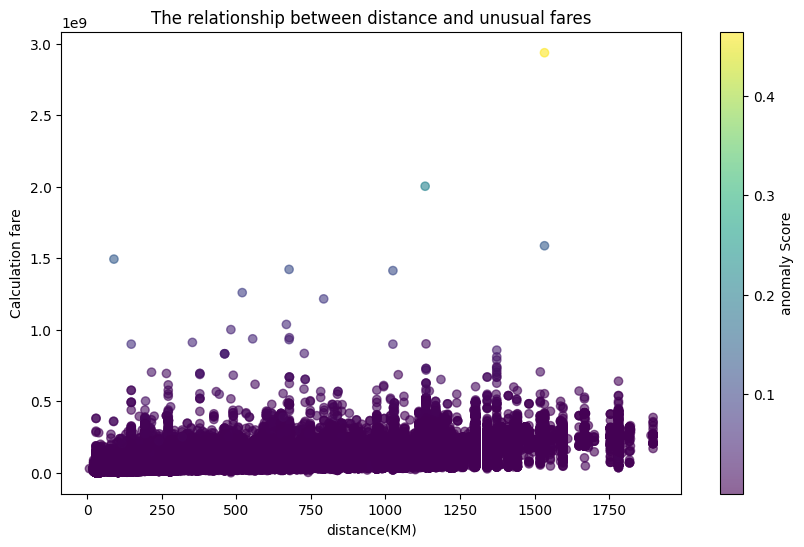

In [ ]:
# جدول کرایه‌های غیرعادی
anomalies = df[df['is_anomaly'] == 1]
print(f"تعداد ناهنجاری‌ها: {len(anomalies)}")

# 10 مورد با بیشترین نمره ناهنجاری
top_anomalies = anomalies.sort_values('anomaly_score', ascending=False).head(10)
print(top_anomalies[['Bill of lading number', 'Company name', 'Calculation fare', 'anomaly_score']])

# ارتباط کرایه و مسافت برای ناهنجاری‌ها
plt.figure(figsize=(10, 6))
plt.scatter(df['distance'], df['Calculation fare'],
            c=df['anomaly_score'],
            cmap='viridis', alpha=0.6)
plt.colorbar(label='anomaly Score')
plt.title('The relationship between distance and unusual fares')
plt.xlabel('distance(KM)')
plt.ylabel('Calculation fare')
plt.show()

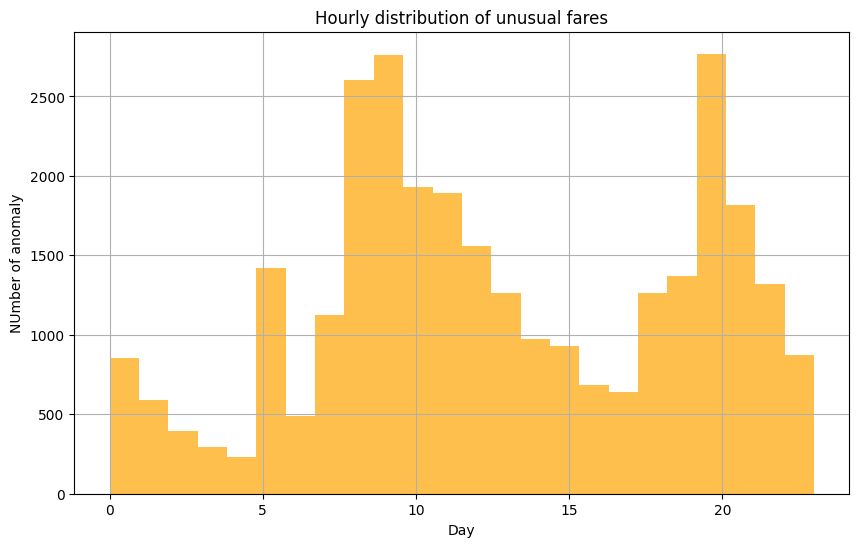

In [ ]:
# بررسی توزیع ساعتی ناهنجاری‌ها
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(anomalies['hour'], bins=24, color='orange', alpha=0.7)
plt.title('Hourly distribution of unusual fares')
plt.xlabel('Day')
plt.ylabel('NUmber of anomaly')
plt.grid(True)
plt.show()

## **بررسی شرکت قصر بار قم**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ghasrbar = df[df['Company name'] == 'قصربار قم'].copy()

metrics = ghasrbar.agg({
    'Calculation fare': ['mean', 'median', 'max', 'min'],
    'distance': ['mean', 'median'],
    'weight': ['mean', 'median'],
    'Bill of lading number': 'count'
}).reset_index()

print("📊 آمار کلی شرکت قصربار قم:")
print(metrics)

📊 آمار کلی شرکت قصربار قم:
    index  Calculation fare    distance       weight  Bill of lading number
0    mean      5.468210e+07  365.132556  5711.299518                    NaN
1  median      3.751607e+07  177.000000  2500.000000                    NaN
2     max      2.937541e+09         NaN          NaN                    NaN
3     min      3.003000e+06         NaN          NaN                    NaN
4   count               NaN         NaN          NaN                36128.0


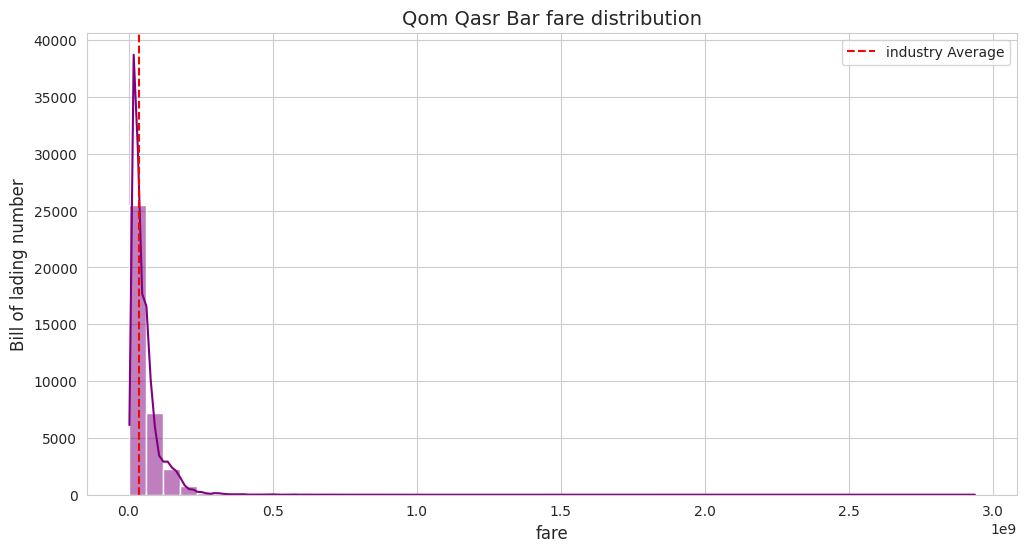

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(ghasrbar['Calculation fare'], bins=50, kde=True, color='purple')
plt.axvline(ghasrbar['Calculation fare'].median(), color='r', linestyle='--', label='industry Average')
plt.title('Qom Qasr Bar fare distribution', fontsize=14)
plt.xlabel('fare', fontsize=12)
plt.ylabel('Bill of lading number', fontsize=12)
plt.legend()
plt.grid(True)
plt.savefig('ghasrbar_fare_distribution.png', dpi=300)

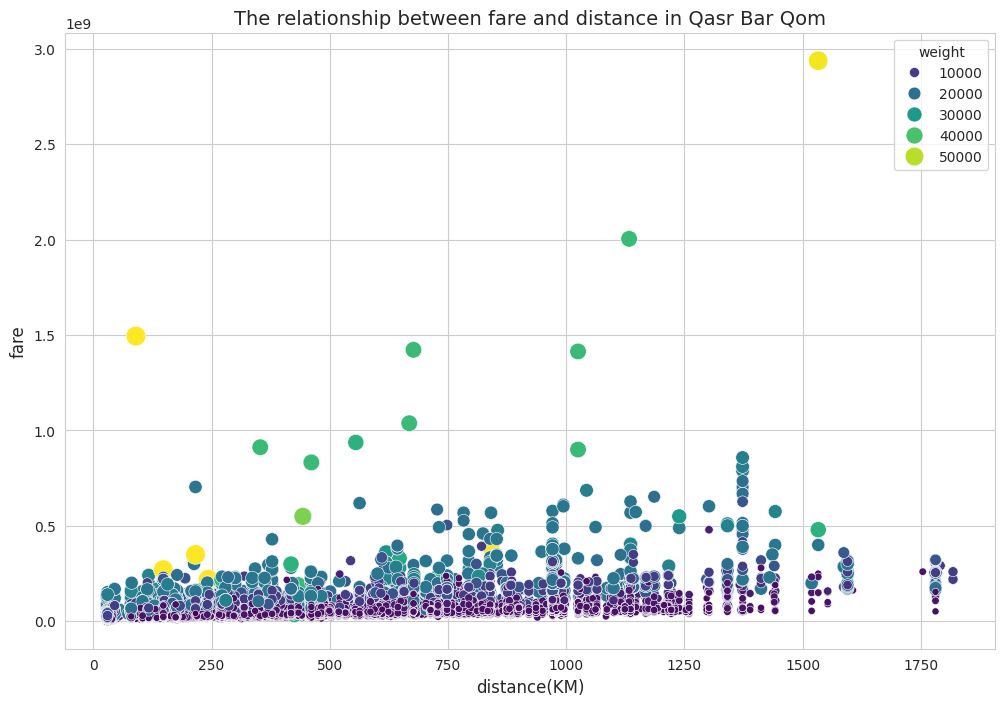

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=ghasrbar, x='distance', y='Calculation fare',
                hue='weight', palette='viridis', size='weight', sizes=(20, 200))
plt.title('The relationship between fare and distance in Qasr Bar Qom', fontsize=14)
plt.xlabel('distance(KM)', fontsize=12)
plt.ylabel('fare', fontsize=12)
plt.grid(True)

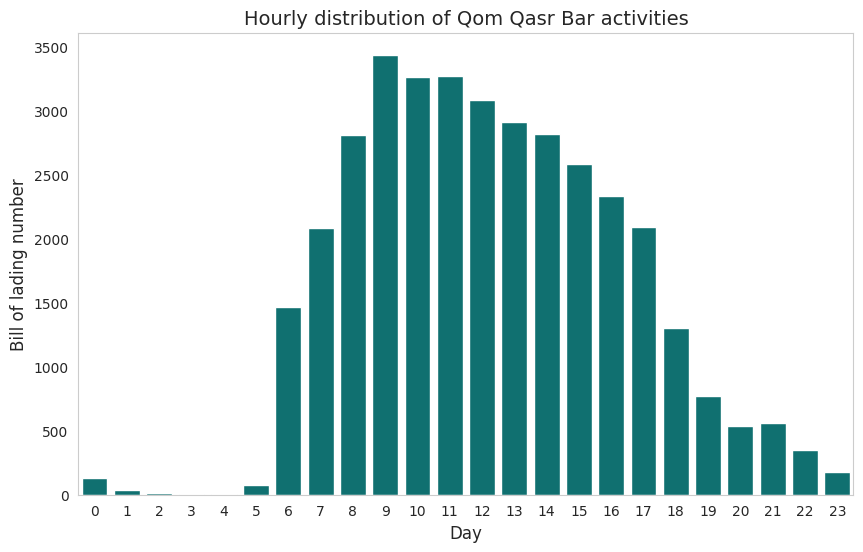

In [ ]:
ghasrbar['hour'] = pd.to_datetime(ghasrbar['Bill of lading registration time']).dt.hour


plt.figure(figsize=(10, 6))
sns.countplot(data=ghasrbar, x='hour', color='teal')
plt.title('Hourly distribution of Qom Qasr Bar activities', fontsize=14)
plt.xlabel('Day-Watch', fontsize=12)
plt.ylabel('Bill of lading number', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y')

In [ ]:
import pandas as pd

# انتخاب 5 شرکت پرتکرار دیگر
top_companies = df['Company name'].value_counts().head(6).index.tolist()
if 'قصربار قم' in top_companies:
    top_companies.remove('قصربار قم')

# افزودن قصربار قم به لیست مقایسه
compare_list = top_companies + ['قصربار قم']

# فیلتر داده‌ها
comparison = df[df['Company name'].isin(compare_list)]

# ساخت جدول خلاصه آماری
summary_table = comparison.groupby('Company name')['Calculation fare'].agg([
    ('تعداد بارنامه', 'count'),
    ('میانگین کرایه (میلیون تومان)', lambda x: x.mean() / 1e6),
    ('میانه کرایه (میلیون تومان)', lambda x: x.median() / 1e6)
]).reset_index()

# مرتب‌سازی بر اساس میانگین
summary_table = summary_table.sort_values(by='میانگین کرایه (میلیون تومان)', ascending=False)

# نمایش جدول
import pandas as pd
from IPython.display import display

display(summary_table)

,Company name,تعداد بارنامه,میانگین کرایه (میلیون تومان),میانه کرایه (میلیون تومان)
3,سعادت کوش قم,63452,94.781748,76.000000
2,روز بار قم,32593,88.453399,70.700000
4,شکوه بار مرکزي قم,40620,86.792599,74.000000
0,امين ترابر,33580,67.806874,57.147300
1,توحيد راه سلفچگان,62257,60.590372,49.315068
5,قصربار قم,36128,54.682103,37.516067


In [ ]:
# یافتن بارنامه‌های با بیشترین نسبت کرایه به مسافت
ghasrbar['fare_per_km'] = ghasrbar['Calculation fare'] / ghasrbar['distance']
suspicious = ghasrbar.sort_values('fare_per_km', ascending=False).head(10)

print(" ۱۰ بارنامه مشکوک با بالاترین نسبت کرایه به مسافت:")
print(suspicious[['Bill of lading number', 'Calculation fare', 'distance', 'fare_per_km']])

 ۱۰ بارنامه مشکوک با بالاترین نسبت کرایه به مسافت:
        Bill of lading number  Calculation fare  distance   fare_per_km
115772                 887698        1494543180        90  1.660604e+07
430246                7931737         152470042        30  5.082335e+06
418805                7931218         152470042        30  5.082335e+06
593470                2592610         139917741        30  4.663925e+06
537327                3972936         139917741        30  4.663925e+06
208804                6972036         131218159        30  4.373939e+06
330843                4471759         125521172        30  4.184039e+06
199037                6971831         120339498        30  4.011317e+06
547870                7335422         169129456        45  3.758432e+06
571086                7336679         169129456        45  3.758432e+06


/tmp/ipython-input-4119905554.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_suspicious, x='Bill of lading number',


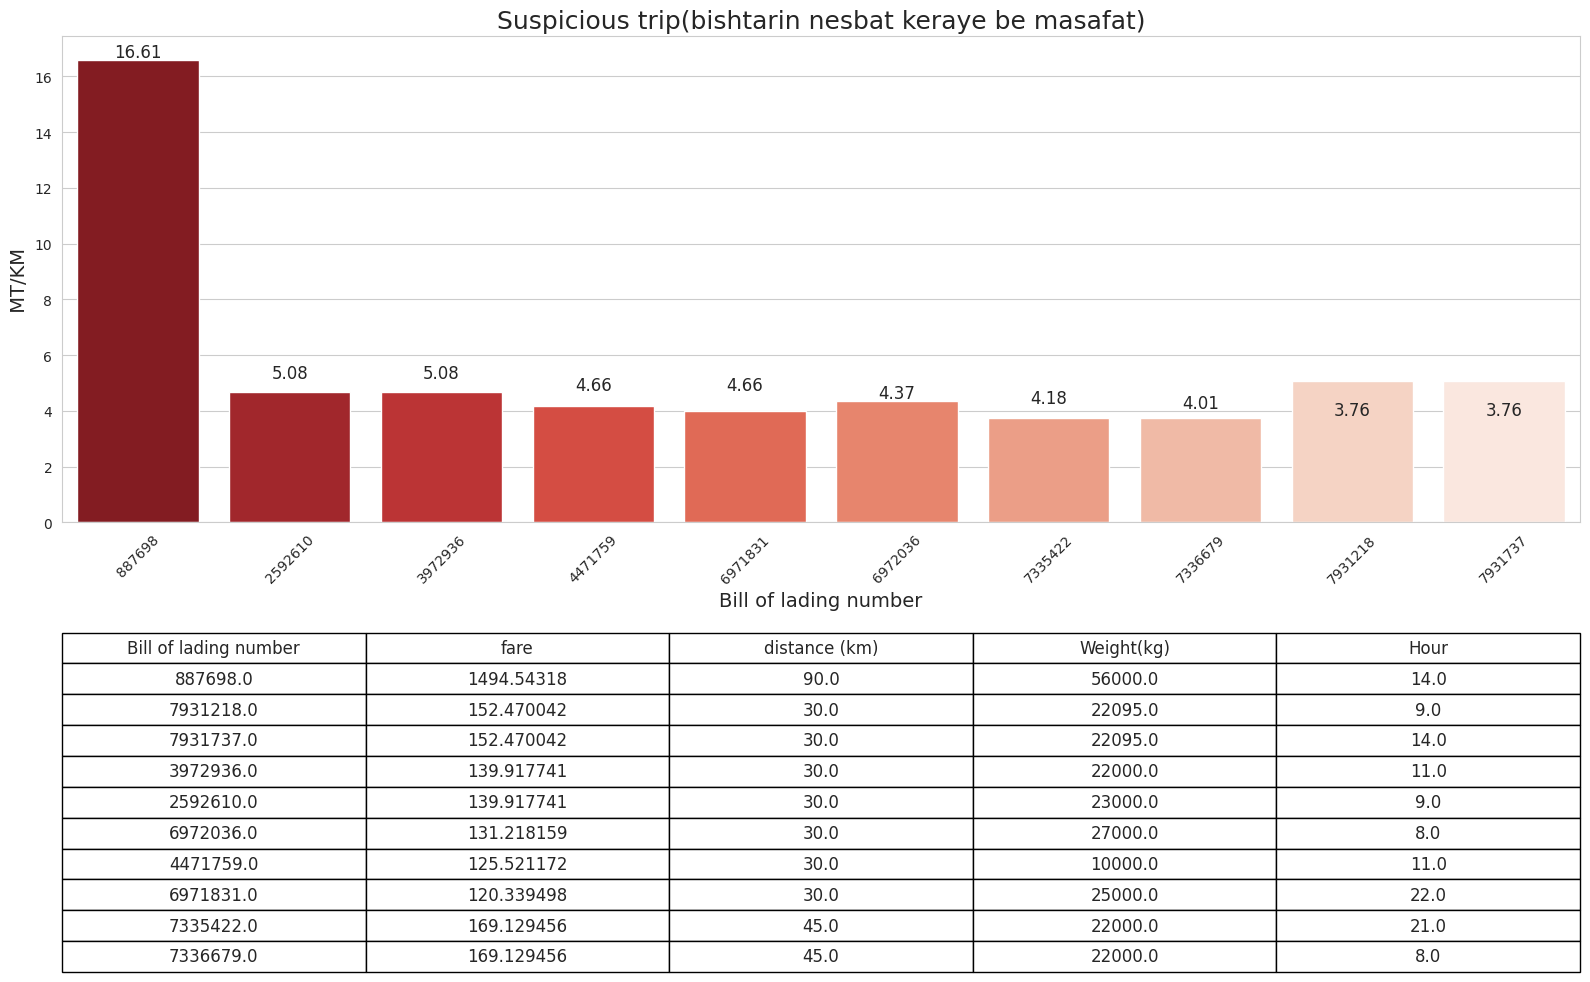

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# انتخاب 10 سفر مشکوک با بیشترین نسبت کرایه به مسافت
top_suspicious = ghasrbar.nlargest(10, 'fare_per_km')

# ایجاد شکل و دو محور (نمودار و جدول)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

# --- نمودار میله‌ای سفرهای مشکوک ---
sns.barplot(data=top_suspicious, x='Bill of lading number',
            y=top_suspicious['fare_per_km'] / 1e6, palette='Reds_r', ax=ax1)
ax1.set_title('Suspicious trip(bishtarin nesbat keraye be masafat)', fontsize=18)
ax1.set_xlabel('Bill of lading number', fontsize=14)
ax1.set_ylabel(' MT/KM ', fontsize=14)
ax1.tick_params(axis='x', rotation=45)

# نمایش مقدار روی میله‌ها
for i, v in enumerate(top_suspicious['fare_per_km'] / 1e6):
    ax1.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=12)

# --- جدول اطلاعات ---
ax2.axis('off')
table_data = top_suspicious[['Bill of lading number', 'Calculation fare',
                             'distance', 'weight', 'hour']].copy()
table_data['Calculation fare'] = table_data['Calculation fare'] / 1e6  # تبدیل به میلیون تومان

table_data = table_data.rename(columns={
    'Bill of lading number': 'Bill of lading number',
    'Calculation fare': 'fare',
    'distance': 'distance (km)',
    'weight': 'Weight(kg)',
    'hour': 'Hour'
})

# نمایش جدول در محور دوم
table = ax2.table(cellText=table_data.values,
                  colLabels=table_data.columns,
                  cellLoc='center',
                  loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

# نهایی‌سازی و نمایش
plt.tight_layout()
plt.show()
